# Traffic Light Event — Segmented Feedback Models

Each event is split into **3 non-overlapping temporal segments**:

| Segment | Phase | Light | Level | Predictor |
|---------|-------|-------|-------|-----------|
| **1** | Approaching (Green, before yellow) | Green | Window | `TTC_min` (capped) |
| **2** | Yellow decision (yellow → entry decision) | Yellow / Red | **Event** | `TTC_min_at_yellow` (snapshot) |
| **3** | Junction traversal (after Model 2 ends) | Any | Window | `Speed_mean` |

**TTC note:** TTC is computed relative to the traffic light (time until the car reaches the light).  
- Segment 1 & 2: TTC decreases as driver approaches. NaN = no obstacle (open road) → fill with 999 then cap at 6s.  
- Segment 3: driver has passed the light → TTC is NaN by definition → use Speed instead.

In [18]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy import stats
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('output/windows_1s_clean.csv')
TTC_CEILING, TTC_NAN_FILL = 6.0, 999.0
SEG_COLORS = {1: '#4878d0', 2: '#ee854a', 3: '#9467bd'}
print(f'Loaded {len(df)} windows, {df["event_id"].nunique()} events')

Loaded 5568 windows, 183 events


## Step 1 — Assign Segment Labels Per Event

**Segment 1:** `Approaching` + `Green` windows strictly before `yellow_transition`

**Segment 2:** from `yellow_transition` window until the *entry decision endpoint*:
- Driver eventually entered on Green (stopped at red first) → endpoint = first window where light turns Red
- Driver entered on Yellow or Red → endpoint = first `is_stopped==1` inside junction OR first `InsideJunction`, whichever comes first

**Segment 3:** Junction windows strictly after the Segment 2 endpoint:
- `InsideJunction` / `LeavingJunction` after Model 2 ends
- If stopped inside junction on Yellow/Red: only post-stop windows count

In [19]:
def assign_segments(event_df):
    edf = event_df.sort_values('start_time').reset_index(drop=True)
    n = len(edf)
    seg = pd.Series([np.nan]*n, dtype=float)

    def is_junction(i): return edf.at[i,'current_phase'] in ('InsideJunction','LeavingJunction')
    def is_approaching(i): return edf.at[i,'current_phase'] == 'Approaching'

    inside_rows = edf.index[edf['current_phase']=='InsideJunction'].tolist()
    fi = inside_rows[0] if inside_rows else None

    yellow_rows = edf.index[edf['yellow_transition']==1].tolist()

    # No yellow transition: Approaching -> Seg 1, junction -> Seg 3
    if not yellow_rows:
        for i in range(n):
            if is_approaching(i): seg[i] = 1
            elif is_junction(i):  seg[i] = 3
        r = seg.copy(); r.index = event_df.index; return r

    yp = yellow_rows[0]

    # Seg 1: all Approaching windows before yellow
    for i in range(yp):
        if is_approaching(i): seg[i] = 1

    # If never entered junction: Seg 2 covers rest of Approaching windows
    if fi is None:
        for i in range(yp, n):
            if is_approaching(i): seg[i] = 2
        r = seg.copy(); r.index = event_df.index; return r

    entry_light = edf.at[fi,'TrafficLight_current']

    if entry_light == 'Green':
        # Stopped at red and waited for green — Seg 2 ends at LAST red window
        red_rows = [i for i in range(yp, n) if edf.at[i,'TrafficLight_current']=='Red']
        seg2_end = red_rows[-1] if red_rows else yp
        for i in range(yp, seg2_end+1):
            if is_approaching(i): seg[i] = 2
        # Seg 3: everything after (Approaching re-approach + junction)
        for i in range(seg2_end+1, n):
            if is_approaching(i) or is_junction(i): seg[i] = 3

    else:
        # Entered on Yellow or Red
        stopped_inside = [i for i in range(fi, n)
                          if is_junction(i) and edf.at[i,'is_stopped']==1]
        if stopped_inside:
            # Stopped inside junction: Seg 2 up to stop, Seg 3 after
            stop_pos = stopped_inside[0]
            for i in range(yp, stop_pos+1):
                if is_approaching(i) or is_junction(i): seg[i] = 2
            for i in range(stop_pos+1, n):
                if is_approaching(i) or is_junction(i): seg[i] = 3
        else:
            # Drove through without stopping: entire journey = Seg 2, no Seg 3
            for i in range(yp, n):
                if is_approaching(i) or is_junction(i): seg[i] = 2

    r = seg.copy(); r.index = event_df.index; return r


# Apply per event
df['segment'] = df.groupby('event_id', group_keys=False).apply(
    lambda g: assign_segments(g), include_groups=False
)

print('Segment distribution (windows):')
print(df['segment'].value_counts(dropna=False).sort_index())
print(f"\nNaN remaining: {df['segment'].isna().sum()}")
print()
print('Feedback windows per segment:')
print(df[df['first_feedback_relavet_to_event']==1]['segment'].value_counts(dropna=False))


Segment distribution (windows):
segment
1.0    3048
2.0    1428
3.0    1092
Name: count, dtype: int64

NaN remaining: 0

Feedback windows per segment:
segment
2.0    40
1.0    14
3.0     3
Name: count, dtype: int64


## Step 2 — TTC Imputation (Segments 1 & 2)

In [20]:
# Apply only to Segments 1 & 2 (before junction — TTC is defined relative to the light)
pre_junction = df['segment'].isin([1.0, 2.0])
df['TTC_imputed'] = np.nan
df.loc[pre_junction, 'TTC_imputed'] = (
    df.loc[pre_junction, 'TTC_min']
    .fillna(TTC_NAN_FILL)   # NaN = open road, no obstacle → very large TTC
    .clip(upper=TTC_CEILING) # cap: anything > 6s → driver is far or stopped
)

print(f'TTC_min raw range:       {df["TTC_min"].min():.2f} – {df["TTC_min"].max():.2f}')
print(f'TTC_imputed range (Seg1+2): {df["TTC_imputed"].min():.2f} – {df["TTC_imputed"].max():.2f}')
print(f'NaN in TTC_min (Seg1+2): {df.loc[pre_junction, "TTC_min"].isna().sum()} windows filled with {TTC_NAN_FILL}→{TTC_CEILING}')

TTC_min raw range:       0.02 – 282343628.80
TTC_imputed range (Seg1+2): 0.02 – 6.00
NaN in TTC_min (Seg1+2): 470 windows filled with 999.0→6.0


## Step 3 — משתני זמן

- **`time_from_event_start`** — שניות מתחילת האירוע (Seg 1: הנהג לא יודע מתי יהיה צהוב)
- **`time_from_seg_start`** — שניות מתחילת הסגמנט (Seg 2/3: הטריגר הוא המעבר לצהוב / כניסה לצומת)

In [21]:
df['time_from_event_start'] = df.groupby('event_id')['start_time'].transform(lambda x: x - x.min())
df['time_from_seg_start']   = np.nan
for _sid in [1.0, 2.0, 3.0]:
    _mask = df['segment'] == _sid
    df.loc[_mask, 'time_from_seg_start'] = (
        df[_mask].groupby('event_id')['start_time'].transform(lambda x: x - x.min())
    )
print('time_from_event_start range:', df['time_from_event_start'].min(), '—', df['time_from_event_start'].max())
print('time_from_seg_start NaN:', df['time_from_seg_start'].isna().sum())

time_from_event_start range: 0.0 — 168.0
time_from_seg_start NaN: 0


## Step 3 — Event Timeline Visualization

Check that segment labels look correct on sample events.

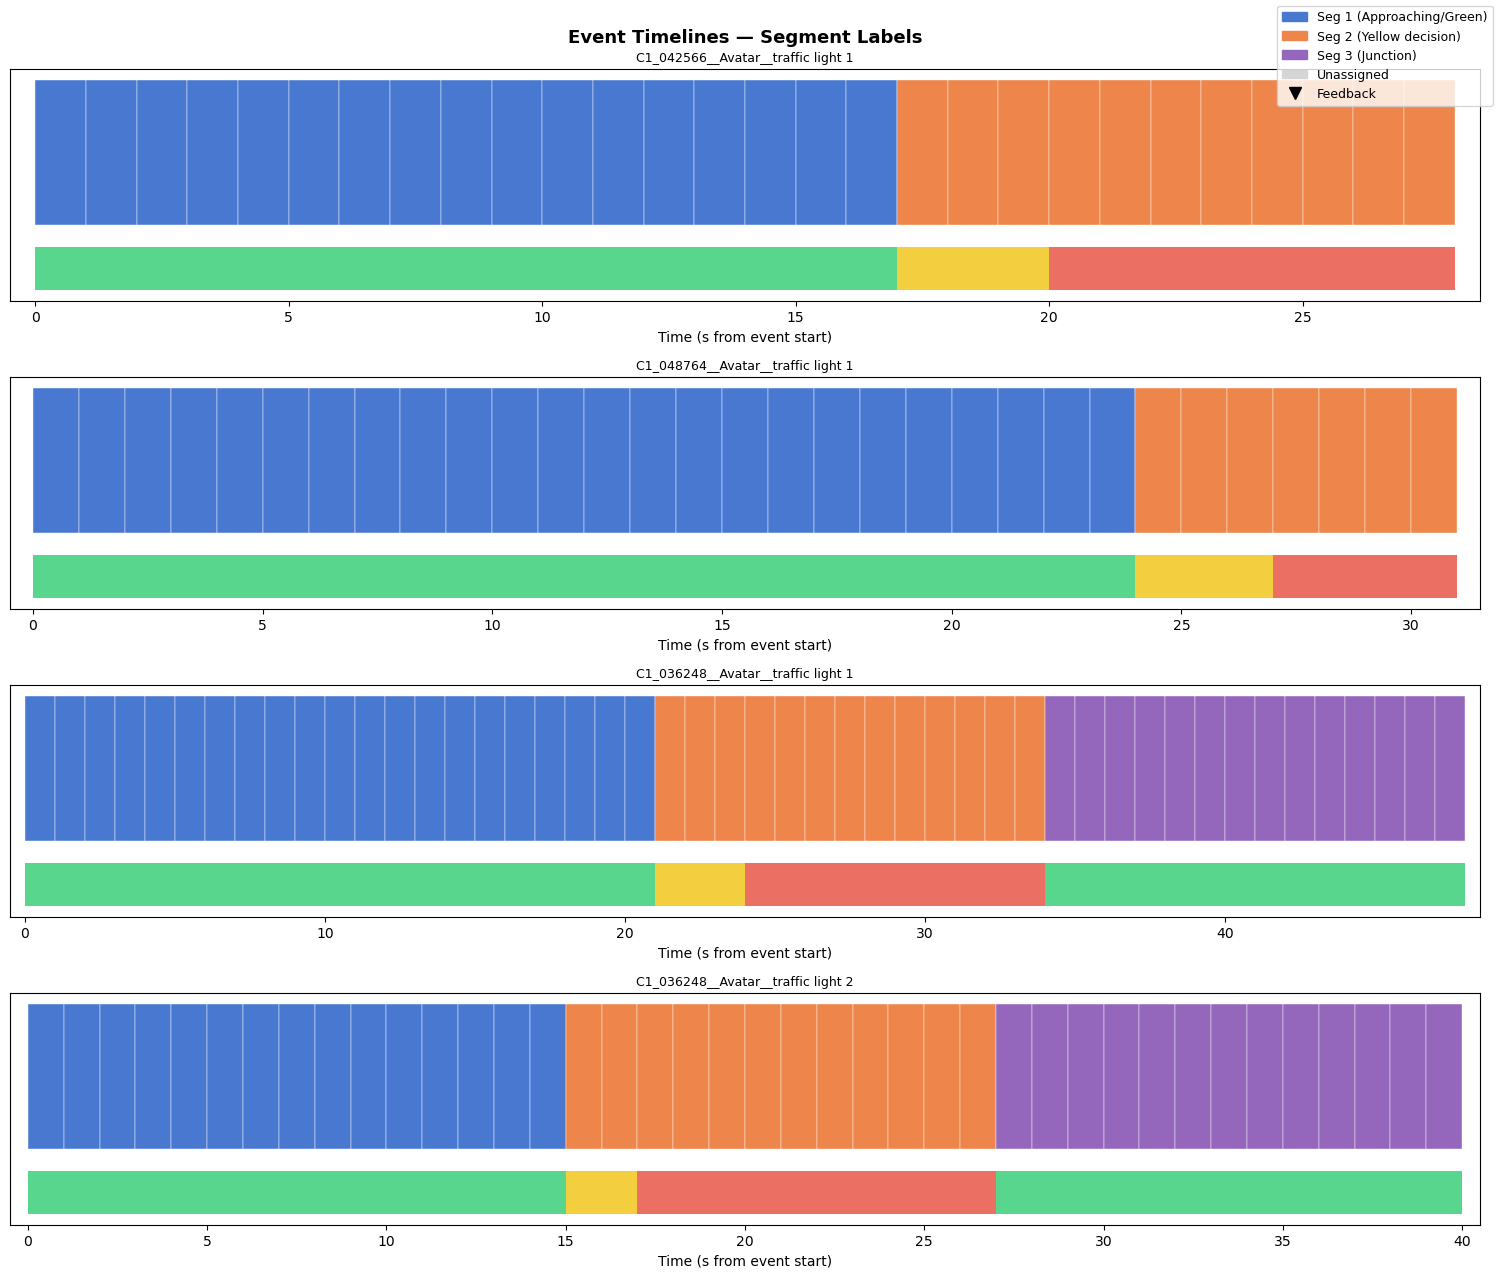

In [22]:

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
SEG_COLORS  = {1: '#4878d0', 2: '#ee854a', 3: '#9467bd'}
SEG_LABELS  = {1: 'Seg 1 (Approaching/Green)', 2: 'Seg 2 (Yellow decision)', 3: 'Seg 3 (Junction)'}
LIGHT_COLOR = {'Green': '#2ecc71', 'Yellow': '#f1c40f', 'Red': '#e74c3c'}

# Pick events: some that went through junction on Yellow/Red, some that stopped
ran_light_events = (
    df[df['current_phase'].isin(['InsideJunction']) & df['TrafficLight_current'].isin(['Yellow','Red'])]
    ['event_id'].unique()[:2]
)
stopped_events = (
    df[df['segment']==3.0]
    .merge(
        df[df['current_phase']=='InsideJunction'].groupby('event_id')['TrafficLight_current'].first().rename('entry_light'),
        on='event_id'
    )
    .query('entry_light=="Green"')['event_id'].unique()[:2]
)
sample_events = list(ran_light_events) + list(stopped_events)

fig, axes = plt.subplots(len(sample_events), 1, figsize=(15, 3.2 * len(sample_events)))
if len(sample_events) == 1:
    axes = [axes]
fig.suptitle('Event Timelines — Segment Labels', fontsize=13, fontweight='bold')

for ax, ev_id in zip(axes, sample_events):
    ev = df[df['event_id'] == ev_id].sort_values('start_time')
    for _, row in ev.iterrows():
        seg_val = row['segment']
        color = SEG_COLORS.get(seg_val, '#d5d5d5')
        ax.barh(0, 1, left=row['start_time'], color=color, height=0.5, edgecolor='white', lw=0.3)
        if row['first_feedback_relavet_to_event'] == 1:
            ax.plot(row['start_time'] + 0.5, 0, 'v', color='black', ms=9, zorder=5)
        # Light color strip below
        ax.barh(-0.4, 1, left=row['start_time'],
                color=LIGHT_COLOR.get(row['TrafficLight_current'], 'grey'), height=0.15, alpha=0.8)
    ax.set_title(ev_id, fontsize=9)
    ax.set_yticks([])
    ax.set_xlabel('Time (s from event start)')
    xlim = (ev['start_time'].min() - 0.5, ev['start_time'].max() + 1.5)
    ax.set_xlim(xlim)

patches = [mpatches.Patch(color=v, label=SEG_LABELS[k]) for k, v in SEG_COLORS.items()]
patches += [mpatches.Patch(color='#d5d5d5', label='Unassigned')]
patches += [plt.Line2D([0],[0], marker='v', color='black', lw=0, ms=8, label='Feedback')]
fig.legend(handles=patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'output', 'event_timeline_segments.png'), dpi=130, bbox_inches='tight')
plt.show()

## Model 1 — Seg 1: התקרבות באור ירוק

**רמה:** חלון (שנייה-שנייה)
**מנבאים:** `TTC_imputed` + `time_from_event_start`
**מטרה:** האם יתן פידבק בחלון הזה?
**מודל:** Logistic Regression (`class_weight='balanced'`)
**מדד:** AUC-ROC

In [23]:
seg1   = df[df['segment'] == 1.0].copy()
X1     = seg1[['TTC_imputed', 'time_from_event_start']].values
y1     = seg1['first_feedback_relavet_to_event'].values

model1 = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model1.fit(X1, y1)
auc1   = roc_auc_score(y1, model1.predict_proba(X1)[:, 1])

print(f'Seg 1  |  n={len(seg1)} windows  |  feedback={y1.sum()}  |  AUC={auc1:.3f}')
print(f'Coef TTC={model1.coef_[0][0]:.3f}   OR={np.exp(model1.coef_[0][0]):.3f}')
print(f'Coef time={model1.coef_[0][1]:.3f}  OR={np.exp(model1.coef_[0][1]):.3f}')

Seg 1  |  n=3048 windows  |  feedback=14  |  AUC=0.600
Coef TTC=-0.201   OR=0.818
Coef time=0.004  OR=1.004


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Seg 1 — Approaching on Green', fontsize=12, fontweight='bold')

t_med   = np.median(seg1['time_from_event_start'])
ttc_med = np.median(seg1['TTC_imputed'])

# TTC effect
ax = axes[0]
ttc_r = np.linspace(seg1['TTC_imputed'].min(), seg1['TTC_imputed'].max(), 300)
grid  = np.column_stack([ttc_r, np.full(300, t_med)])
ax.scatter(seg1['TTC_imputed'], y1 + np.random.uniform(-0.03,0.03,len(y1)), alpha=0.2, s=15, color='#4878d0')
ax.plot(ttc_r, model1.predict_proba(grid)[:, 1], color='crimson', lw=2.5, label=f'AUC={auc1:.2f}')
ax.set_xlabel('TTC (s, cap 6s)'); ax.set_ylabel('P(feedback)')
ax.set_title(f'TTC effect (time={t_med:.0f}s fixed)\nCoef={model1.coef_[0][0]:.3f}')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)

# Time effect
ax = axes[1]
time_r = np.linspace(seg1['time_from_event_start'].min(), seg1['time_from_event_start'].max(), 300)
grid2  = np.column_stack([np.full(300, ttc_med), time_r])
ax.scatter(seg1['time_from_event_start'], y1 + np.random.uniform(-0.03,0.03,len(y1)), alpha=0.2, s=15, color='#4878d0')
ax.plot(time_r, model1.predict_proba(grid2)[:, 1], color='darkorange', lw=2.5, label=f'AUC={auc1:.2f}')
ax.set_xlabel('Time from event start (s)'); ax.set_ylabel('P(feedback)')
ax.set_title(f'Time effect (TTC={ttc_med:.1f}s fixed)\nCoef={model1.coef_[0][1]:.3f}')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)

# Distribution
ax = axes[2]
ax.hist(seg1.loc[y1==0,'TTC_imputed'], bins=30, alpha=0.6, color='#4878d0', density=True, label=f'No feedback (n={(y1==0).sum()})')
ax.hist(seg1.loc[y1==1,'TTC_imputed'], bins=10, alpha=0.85, color='crimson', density=True, label=f'Feedback (n={y1.sum()})')
ax.set_xlabel('TTC (s)'); ax.set_ylabel('Density'); ax.set_title('TTC distribution by class')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

### Kaplan-Meier — Seg 1
חלוקה לפי TTC ממוצע בסגמנט (חציון): נמוך vs גבוה

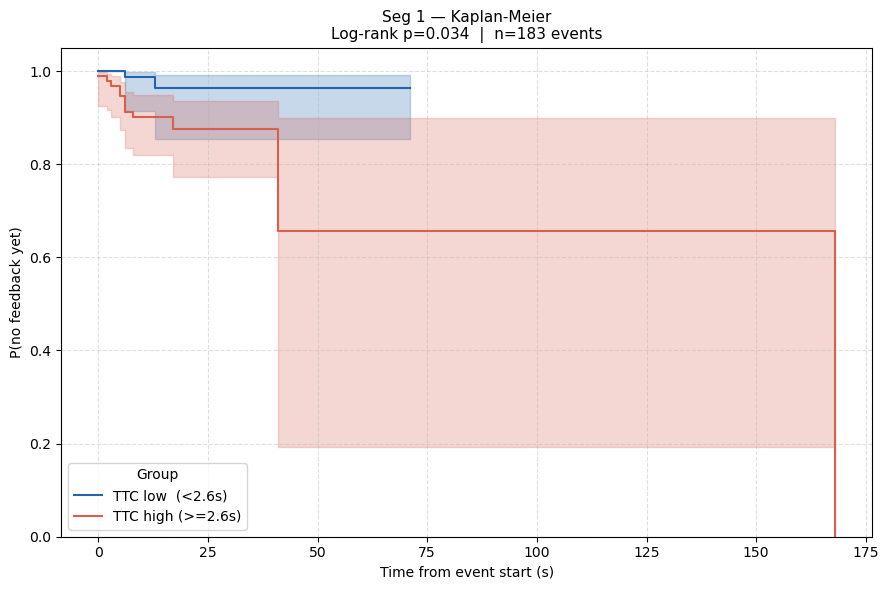

In [25]:
km1_rows = []
for ev_id, g in seg1.groupby('event_id'):
    g    = g.sort_values('start_time')
    fb   = g[g['first_feedback_relavet_to_event']==1]
    km1_rows.append({
        'duration': fb['time_from_event_start'].iloc[0] if len(fb) else g['time_from_event_start'].max(),
        'event':    1 if len(fb) else 0,
        'TTC_mean': g['TTC_imputed'].mean()
    })
km1_df = pd.DataFrame(km1_rows)
med1   = km1_df['TTC_mean'].median()
km1_df['group'] = (km1_df['TTC_mean'] >= med1).astype(int)

fig, ax = plt.subplots(figsize=(9, 6))
kmf = KaplanMeierFitter()
for g_val, color, lbl in [
    (0, '#2166ac', f'TTC low  (<{med1:.1f}s)'),
    (1, '#d6604d', f'TTC high (>={med1:.1f}s)')
]:
    mask = km1_df['group'] == g_val
    kmf.fit(km1_df.loc[mask,'duration'], event_observed=km1_df.loc[mask,'event'], label=lbl)
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)
res1_km = logrank_test(
    km1_df.loc[km1_df['group']==0,'duration'], km1_df.loc[km1_df['group']==1,'duration'],
    event_observed_A=km1_df.loc[km1_df['group']==0,'event'],
    event_observed_B=km1_df.loc[km1_df['group']==1,'event'])
ax.set_title(f'Seg 1 — Kaplan-Meier\nLog-rank p={res1_km.p_value:.3f}  |  n={len(km1_df)} events', fontsize=11)
ax.set_xlabel('Time from event start (s)'); ax.set_ylabel('P(no feedback yet)')
ax.set_ylim(0,1.05); ax.grid(True, ls='--', alpha=0.4); ax.legend(title='Group')
plt.tight_layout(); plt.show()

### Kaplan-Meier — Seg 1: ציר TTC
X = TTC בעת קבלת הפידבק. עקומה אחת — ירידה = פידבק ניתן כשהנהג מתקרב (TTC יורד).

In [ ]:
km1_ttc_rows = []
for ev_id, g in seg1.groupby('event_id'):
    g  = g.sort_values('start_time')
    fb = g[g['first_feedback_relavet_to_event']==1]
    ttc_val = fb['TTC_imputed'].iloc[0] if len(fb) else g['TTC_imputed'].min()
    km1_ttc_rows.append({'ttc': ttc_val, 'event': 1 if len(fb) else 0})
km1_ttc = pd.DataFrame(km1_ttc_rows).dropna(subset=['ttc'])

fig, ax = plt.subplots(figsize=(9, 6))
kmf = KaplanMeierFitter()
kmf.fit(km1_ttc['ttc'], event_observed=km1_ttc['event'],
        label=f'Seg 1 (n={len(km1_ttc)} events, {int(km1_ttc["event"].sum())} feedback)')
kmf.plot_survival_function(ax=ax, ci_show=True, color='#4878d0')
ax.invert_xaxis()
ax.set_title('Seg 1 — Kaplan-Meier by TTC\n(X decreasing = driver approaching traffic light)', fontsize=11)
ax.set_xlabel('TTC (s)   ←   approaching')
ax.set_ylabel('P(no feedback yet)')
ax.set_ylim(0, 1.05)
ax.grid(True, ls='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

## Model 2A — Seg 2: החלטת הצהוב (רמת אירוע)

**רמה:** אירוע (ערך יחיד לכל אירוע)
**מנבא:** `TTC_at_yellow`
**מטרה:** האם יתן פידבק בסגמנט 2?

## Model 2B — Seg 2: חלון-חלון

**רמה:** חלון (שנייה-שנייה)
**מנבאים:** `Speed_mean` + `time_from_seg_start` (מהצהוב)
**הסבר:** TTC לא מוגדר לאחר מעבר הרמזור — משתמשים במהירות

In [27]:
# Model 2A - event level
ttc_yel  = (df[df['yellow_transition']==1].sort_values('start_time')
            .groupby('event_id').first()[['TTC_imputed']]
            .rename(columns={'TTC_imputed':'TTC_at_yellow'}))
seg2_fb  = (df[df['segment']==2.0].groupby('event_id')['first_feedback_relavet_to_event']
            .max().rename('feedback_in_seg2'))
ev2      = ttc_yel.join(seg2_fb, how='inner').dropna(subset=['TTC_at_yellow'])
X2a      = ev2[['TTC_at_yellow']].values
y2a      = ev2['feedback_in_seg2'].fillna(0).values
r2, p2   = stats.pointbiserialr(y2a, X2a.ravel())
model2a  = LogisticRegression(class_weight='balanced', random_state=42).fit(X2a, y2a)
auc2a    = roc_auc_score(y2a, model2a.predict_proba(X2a)[:,1])
print(f'Seg 2A  |  n={len(ev2)} events  |  fb={y2a.sum()}  |  AUC={auc2a:.3f}  |  r={r2:.3f} p={p2:.3f}')

# Model 2B - window level
seg2    = df[df['segment']==2.0].copy()
X2b     = seg2[['Speed_mean','time_from_seg_start']].values
y2b     = seg2['first_feedback_relavet_to_event'].values
model2b = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000).fit(X2b, y2b)
auc2b   = roc_auc_score(y2b, model2b.predict_proba(X2b)[:,1])
print(f'Seg 2B  |  n={len(seg2)} windows  |  fb={y2b.sum()}  |  AUC={auc2b:.3f}')
print(f'  Coef speed={model2b.coef_[0][0]:.3f}  Coef time={model2b.coef_[0][1]:.3f}')

Seg 2A  |  n=144 events  |  fb=40  |  AUC=0.556  |  r=0.072 p=0.391
Seg 2B  |  n=1428 windows  |  fb=40  |  AUC=0.520
  Coef speed=0.009  Coef time=0.036


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Seg 2 — Yellow Decision Zone', fontsize=13, fontweight='bold')

# 2A probability curve
ax = axes[0][0]
tl2 = np.linspace(ev2['TTC_at_yellow'].min(), ev2['TTC_at_yellow'].max(), 300).reshape(-1,1)
ax.scatter(ev2['TTC_at_yellow'], y2a + np.random.uniform(-0.04,0.04,len(y2a)), alpha=0.55, s=40, color='#ee854a')
ax.plot(tl2, model2a.predict_proba(tl2)[:,1], color='crimson', lw=2.5, label=f'AUC={auc2a:.2f}')
ax.set_xlabel('TTC at yellow (s)'); ax.set_ylabel('P(feedback in Seg 2)')
ax.set_title(f'2A — Event level: TTC at yellow\n(n={len(ev2)} events, r={r2:.3f}, p={p2:.3f})')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)

# 2A distribution
ax = axes[0][1]
ax.hist(ev2.loc[y2a==0,'TTC_at_yellow'], bins=20, alpha=0.6, color='#ee854a', density=True, label=f'No fb (n={(y2a==0).sum()})')
ax.hist(ev2.loc[y2a==1,'TTC_at_yellow'], bins=15, alpha=0.85, color='crimson', density=True, label=f'Feedback (n={y2a.sum()})')
ax.set_xlabel('TTC at yellow (s)'); ax.set_ylabel('Density'); ax.set_title('2A — TTC distribution')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)

# 2B speed effect
t_med2 = np.median(seg2['time_from_seg_start'])
ax = axes[1][0]
spd_r  = np.linspace(seg2['Speed_mean'].min(), seg2['Speed_mean'].max(), 300)
ax.scatter(seg2['Speed_mean'], y2b + np.random.uniform(-0.03,0.03,len(y2b)), alpha=0.2, s=15, color='#ee854a')
ax.plot(spd_r, model2b.predict_proba(np.column_stack([spd_r, np.full(300,t_med2)]))[:,1],
        color='crimson', lw=2.5, label=f'AUC={auc2b:.2f}')
ax.set_xlabel('Speed (m/s)'); ax.set_ylabel('P(feedback)')
ax.set_title(f'2B — Window level: speed effect\n(time={t_med2:.0f}s fixed)')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)

# 2B time effect
spd_med2 = np.median(seg2['Speed_mean'])
ax = axes[1][1]
time_r2  = np.linspace(seg2['time_from_seg_start'].min(), seg2['time_from_seg_start'].max(), 300)
ax.scatter(seg2['time_from_seg_start'], y2b + np.random.uniform(-0.03,0.03,len(y2b)), alpha=0.2, s=15, color='#ee854a')
ax.plot(time_r2, model2b.predict_proba(np.column_stack([np.full(300,spd_med2), time_r2]))[:,1],
        color='darkorange', lw=2.5, label=f'AUC={auc2b:.2f}')
ax.set_xlabel('Time from yellow (s)'); ax.set_ylabel('P(feedback)')
ax.set_title(f'2B — Window level: time effect\n(speed={spd_med2:.1f} fixed)')
ax.legend(); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

### Kaplan-Meier — Seg 2
חלוקה לפי TTC בצהוב (חציון)

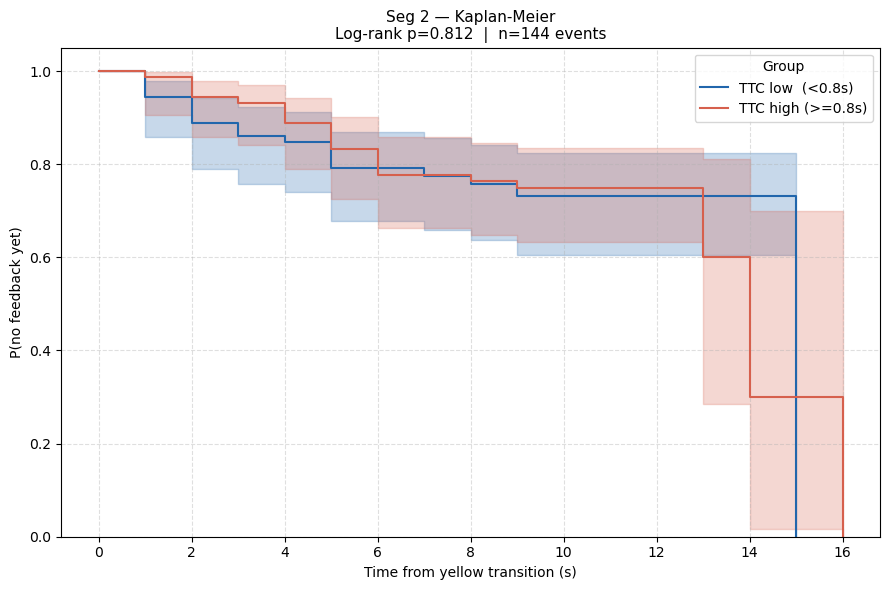

In [29]:
ev2_km = ev2.copy()
ev2_km['duration'] = np.nan; ev2_km['event_km'] = 0
for ev_id, g in df[df['segment']==2.0].groupby('event_id'):
    fb = g[g['first_feedback_relavet_to_event']==1]
    ev2_km.loc[ev_id,'duration'] = fb['time_from_seg_start'].iloc[0] if len(fb) else g['time_from_seg_start'].max()
    ev2_km.loc[ev_id,'event_km'] = 1 if len(fb) else 0
ev2_km = ev2_km.dropna(subset=['duration','TTC_at_yellow'])
med2   = ev2_km['TTC_at_yellow'].median()
ev2_km['group'] = (ev2_km['TTC_at_yellow'] >= med2).astype(int)

fig, ax = plt.subplots(figsize=(9, 6))
kmf = KaplanMeierFitter()
for g_val, color, lbl in [
    (0, '#2166ac', f'TTC low  (<{med2:.1f}s)'),
    (1, '#d6604d', f'TTC high (>={med2:.1f}s)')
]:
    mask = ev2_km['group'] == g_val
    kmf.fit(ev2_km.loc[mask,'duration'], event_observed=ev2_km.loc[mask,'event_km'], label=lbl)
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)
res2_km = logrank_test(
    ev2_km.loc[ev2_km['group']==0,'duration'], ev2_km.loc[ev2_km['group']==1,'duration'],
    event_observed_A=ev2_km.loc[ev2_km['group']==0,'event_km'],
    event_observed_B=ev2_km.loc[ev2_km['group']==1,'event_km'])
ax.set_title(f'Seg 2 — Kaplan-Meier\nLog-rank p={res2_km.p_value:.3f}  |  n={len(ev2_km)} events', fontsize=11)
ax.set_xlabel('Time from yellow transition (s)'); ax.set_ylabel('P(no feedback yet)')
ax.set_ylim(0,1.05); ax.grid(True, ls='--', alpha=0.4); ax.legend(title='Group')
plt.tight_layout(); plt.show()

### Kaplan-Meier — Seg 2: ציר TTC
X = TTC בעת קבלת הפידבק. עקומה אחת — ירידה = פידבק ניתן כשהנהג מתקרב (TTC יורד).

In [ ]:
km2_ttc_rows = []
for ev_id, g in df[df['segment']==2.0].groupby('event_id'):
    g  = g.sort_values('start_time')
    fb = g[g['first_feedback_relavet_to_event']==1]
    ttc_val = fb['TTC_imputed'].iloc[0] if len(fb) else g['TTC_imputed'].min()
    km2_ttc_rows.append({'ttc': ttc_val, 'event': 1 if len(fb) else 0})
km2_ttc = pd.DataFrame(km2_ttc_rows).dropna(subset=['ttc'])

fig, ax = plt.subplots(figsize=(9, 6))
kmf = KaplanMeierFitter()
kmf.fit(km2_ttc['ttc'], event_observed=km2_ttc['event'],
        label=f'Seg 2 (n={len(km2_ttc)} events, {int(km2_ttc["event"].sum())} feedback)')
kmf.plot_survival_function(ax=ax, ci_show=True, color='#ee854a')
ax.invert_xaxis()
ax.set_title('Seg 2 — Kaplan-Meier by TTC\n(X decreasing = driver approaching traffic light)', fontsize=11)
ax.set_xlabel('TTC (s)   ←   approaching')
ax.set_ylabel('P(no feedback yet)')
ax.set_ylim(0, 1.05)
ax.grid(True, ls='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

## Model 3 — Seg 3: חציית הצומת

**רמה:** חלון (שנייה-שנייה)
**מנבאים:** `Speed_mean` + `time_from_seg_start`
**חלוקה:** נפרד לכניסה בירוק ולכניסה בצהוב/אדום

In [31]:
seg3      = df[df['segment'] == 3.0].copy()
entry_col = (df[df['current_phase']=='InsideJunction'].sort_values('start_time')
             .groupby('event_id').first()[['TrafficLight_current']]
             .rename(columns={'TrafficLight_current':'entry_light'}))
seg3 = seg3.merge(entry_col, on='event_id', how='left')
seg3['entry_group'] = seg3['entry_light'].map(lambda x: 'Green' if x=='Green' else 'Yellow/Red')
seg3a = seg3[seg3['entry_group']=='Green']
seg3b = seg3[seg3['entry_group']=='Yellow/Red']
print(f'Seg 3a (Green entry):     {len(seg3a)} windows, {seg3a["first_feedback_relavet_to_event"].sum()} feedback')
print(f'Seg 3b (Yellow/Red entry): {len(seg3b)} windows, {seg3b["first_feedback_relavet_to_event"].sum()} feedback')

Seg 3a (Green entry):     1032 windows, 2 feedback
Seg 3b (Yellow/Red entry): 60 windows, 1 feedback


In [32]:
def fit_seg3(data, label):
    X = data[['Speed_mean', 'time_from_seg_start']].values
    y = data['first_feedback_relavet_to_event'].values
    if y.sum() == 0 or (1-y).sum() == 0:
        print(f'{label}: single class — cannot fit'); return None, np.nan, y
    m   = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000).fit(X, y)
    auc = roc_auc_score(y, m.predict_proba(X)[:,1])
    print(f'{label}  |  n={len(data)}  |  fb={y.sum()}  |  AUC={auc:.3f}')
    print(f'  Coef speed={m.coef_[0][0]:.3f}  Coef time={m.coef_[0][1]:.3f}')
    return m, auc, y

model3a, auc3a, y3a = fit_seg3(seg3a, 'Seg 3a — Green entry')
model3b, auc3b, y3b = fit_seg3(seg3b, 'Seg 3b — Yellow/Red entry')

Seg 3a — Green entry  |  n=1032  |  fb=2  |  AUC=0.703
  Coef speed=0.071  Coef time=0.003
Seg 3b — Yellow/Red entry  |  n=60  |  fb=1  |  AUC=0.907
  Coef speed=-0.753  Coef time=-0.897


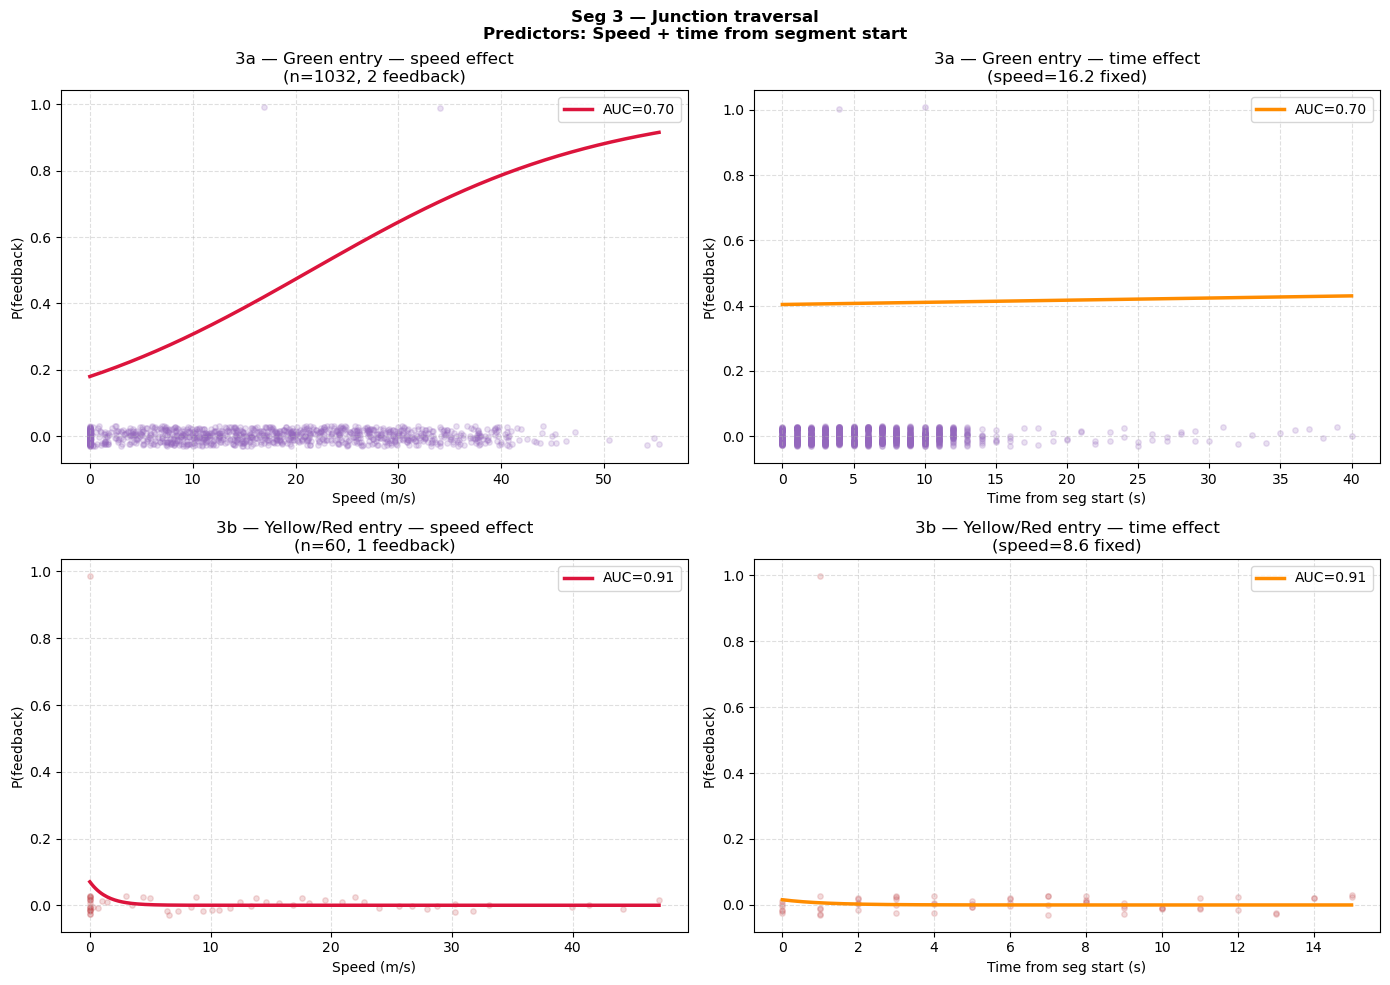

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Seg 3 — Junction traversal\nPredictors: Speed + time from segment start', fontsize=12, fontweight='bold')

for row_idx, (sub, model, auc, y_sub, label, color) in enumerate([
    (seg3a, model3a, auc3a, y3a, '3a — Green entry',      '#9467bd'),
    (seg3b, model3b, auc3b, y3b, '3b — Yellow/Red entry', '#c44e52'),
]):
    ax_s = axes[row_idx][0]; ax_t = axes[row_idx][1]
    if model is None:
        for ax in [ax_s, ax_t]:
            ax.text(0.5,0.5,'Insufficient data',ha='center',va='center',transform=ax.transAxes)
        continue
    t_med   = np.median(sub['time_from_seg_start'])
    spd_med = np.median(sub['Speed_mean'])
    spd_r   = np.linspace(sub['Speed_mean'].min(), sub['Speed_mean'].max(), 300)
    time_r  = np.linspace(sub['time_from_seg_start'].min(), sub['time_from_seg_start'].max(), 300)

    ax_s.scatter(sub['Speed_mean'], y_sub + np.random.uniform(-0.03,0.03,len(y_sub)), alpha=0.2, s=15, color=color)
    ax_s.plot(spd_r, model.predict_proba(np.column_stack([spd_r, np.full(300,t_med)]))[:,1],
              color='crimson', lw=2.5, label=f'AUC={auc:.2f}')
    ax_s.set_xlabel('Speed (m/s)'); ax_s.set_ylabel('P(feedback)')
    ax_s.set_title(f'{label} — speed effect\n(n={len(sub)}, {int(y_sub.sum())} feedback)')
    ax_s.legend(); ax_s.grid(True, ls='--', alpha=0.4)

    ax_t.scatter(sub['time_from_seg_start'], y_sub + np.random.uniform(-0.03,0.03,len(y_sub)), alpha=0.2, s=15, color=color)
    ax_t.plot(time_r, model.predict_proba(np.column_stack([np.full(300,spd_med), time_r]))[:,1],
              color='darkorange', lw=2.5, label=f'AUC={auc:.2f}')
    ax_t.set_xlabel('Time from seg start (s)'); ax_t.set_ylabel('P(feedback)')
    ax_t.set_title(f'{label} — time effect\n(speed={spd_med:.1f} fixed)')
    ax_t.legend(); ax_t.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

### Kaplan-Meier — Seg 3
חלוקה לפי מהירות ממוצעת (חציון)

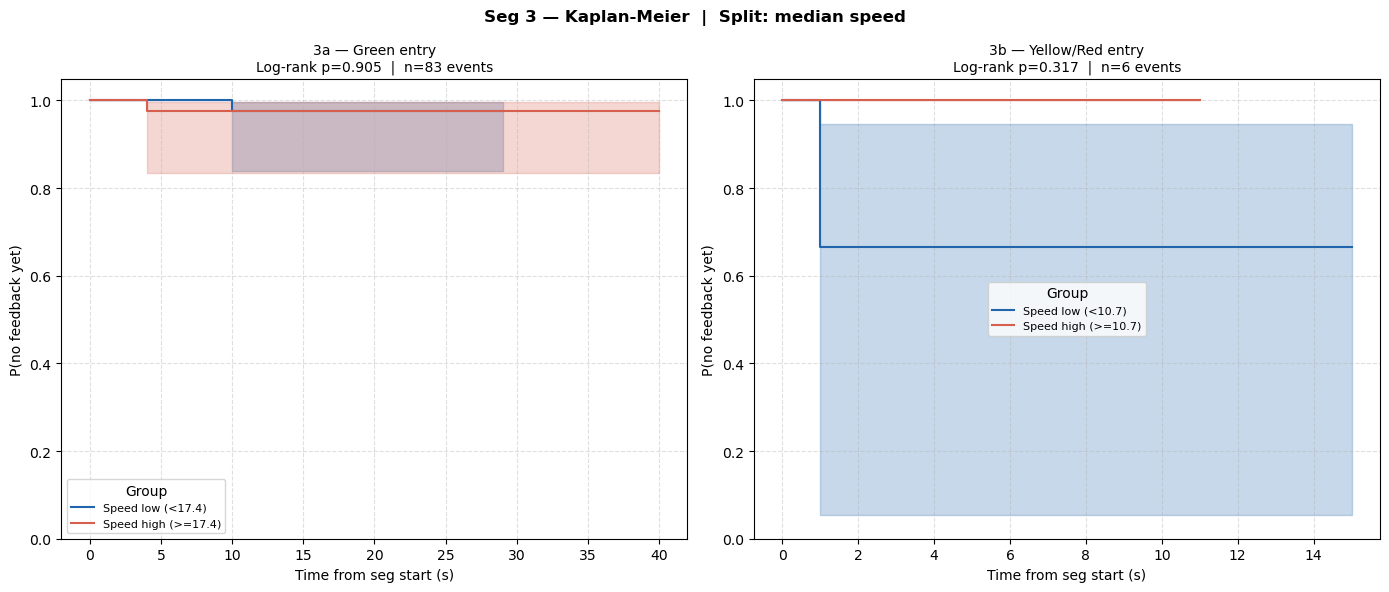

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Seg 3 — Kaplan-Meier  |  Split: median speed', fontsize=12, fontweight='bold')
for ax, (sub, label) in zip(axes, [(seg3a,'3a — Green entry'),(seg3b,'3b — Yellow/Red entry')]):
    km_rows = []
    for ev_id, g in sub.groupby('event_id'):
        g  = g.sort_values('start_time')
        fb = g[g['first_feedback_relavet_to_event']==1]
        km_rows.append({'duration': fb['time_from_seg_start'].iloc[0] if len(fb) else g['time_from_seg_start'].max(),
                        'event': 1 if len(fb) else 0, 'Speed': g['Speed_mean'].mean()})
    km_df = pd.DataFrame(km_rows)
    if len(km_df) < 3:
        ax.text(0.5,0.5,'Insufficient data',ha='center',va='center',transform=ax.transAxes); continue
    med_spd = km_df['Speed'].median()
    km_df['group'] = (km_df['Speed'] >= med_spd).astype(int)
    kmf = KaplanMeierFitter()
    for g_val, color, lbl in [(0,'#2166ac',f'Speed low (<{med_spd:.1f})'),(1,'#d6604d',f'Speed high (>={med_spd:.1f})')]:
        mask = km_df['group']==g_val
        kmf.fit(km_df.loc[mask,'duration'], event_observed=km_df.loc[mask,'event'], label=lbl)
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color)
    res3_km = logrank_test(km_df.loc[km_df['group']==0,'duration'], km_df.loc[km_df['group']==1,'duration'],
                           event_observed_A=km_df.loc[km_df['group']==0,'event'],
                           event_observed_B=km_df.loc[km_df['group']==1,'event'])
    ax.set_title(f'{label}\nLog-rank p={res3_km.p_value:.3f}  |  n={len(km_df)} events', fontsize=10)
    ax.set_xlabel('Time from seg start (s)'); ax.set_ylabel('P(no feedback yet)')
    ax.set_ylim(0,1.05); ax.grid(True, ls='--', alpha=0.4); ax.legend(title='Group', fontsize=8)
plt.tight_layout(); plt.show()

### Kaplan-Meier — Seg 3: TTC לא רלוונטי
בסגמנט 3 הנהג נמצא בתוך הצומת — TTC אינו מוגדר. ניתוח הישרדות לפי TTC אינו ישים כאן.

## סיכום — ביצועי כל המודלים

  SEGMENTED MODEL SUMMARY
  Model     Predictors                    n        FB     AUC
  ------------------------------------------------------------
  Seg 1     TTC + time (event start)      3048     14     0.600
  Seg 2A    TTC at yellow (event)         144      40     0.556
  Seg 2B    Speed + time (yellow)         1428     40     0.520
  Seg 3a    Speed + time (green)          1032     2      0.703
  Seg 3b    Speed + time (yel/red)        60       1      0.907


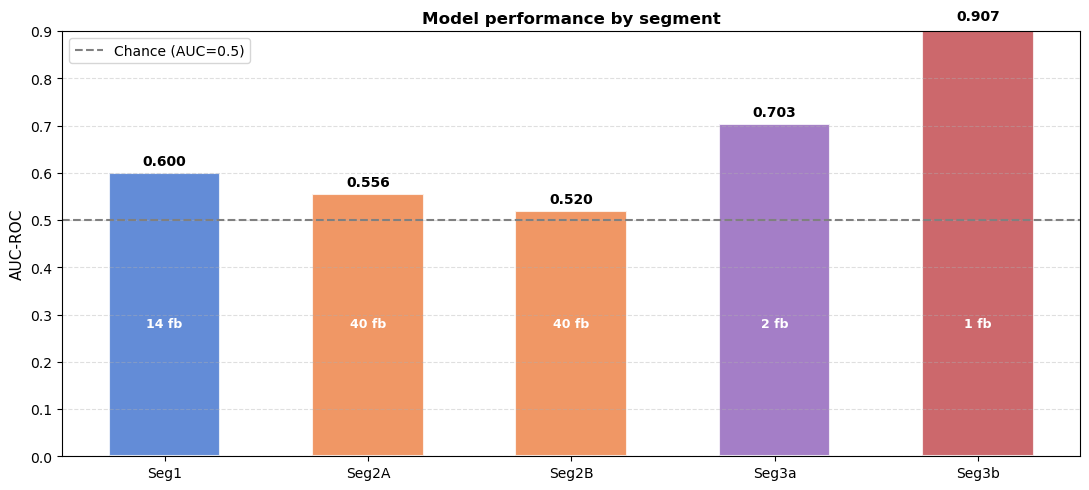

In [35]:
print('=' * 70)
print('  SEGMENTED MODEL SUMMARY')
print('=' * 70)
rows = [
    ('Seg 1',  'TTC + time (event start)', len(seg1),  int(y1.sum()),  auc1),
    ('Seg 2A', 'TTC at yellow (event)',    len(ev2),   int(y2a.sum()), auc2a),
    ('Seg 2B', 'Speed + time (yellow)',    len(seg2),  int(y2b.sum()), auc2b),
    ('Seg 3a', 'Speed + time (green)',     len(seg3a), int(y3a.sum() if y3a is not None else 0), auc3a),
    ('Seg 3b', 'Speed + time (yel/red)',   len(seg3b), int(y3b.sum() if y3b is not None else 0), auc3b),
]
print(f'  {"Model":<8}  {"Predictors":<28}  {"n":<7}  {"FB":<5}  AUC')
print('  ' + '-' * 60)
for name, pred, n, fb, auc in rows:
    print(f'  {name:<8}  {pred:<28}  {n:<7}  {fb:<5}  {auc:.3f}' if not np.isnan(auc) else f'  {name:<8}  {pred:<28}  {n:<7}  {fb:<5}  N/A')

# AUC bar chart
valid = [(nm, a, c, fb) for nm,a,c,fb in zip(
    ['Seg1','Seg2A','Seg2B','Seg3a','Seg3b'],
    [auc1,auc2a,auc2b,auc3a,auc3b],
    ['#4878d0','#ee854a','#ee854a','#9467bd','#c44e52'],
    [int(y1.sum()),int(y2a.sum()),int(y2b.sum()),
     int(y3a.sum() if y3a is not None else 0),
     int(y3b.sum() if y3b is not None else 0)]
) if not np.isnan(a)]
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar([v[0] for v in valid],[v[1] for v in valid],color=[v[2] for v in valid],
              alpha=0.85, edgecolor='white', lw=1.5, width=0.55)
ax.axhline(0.5, color='grey', ls='--', lw=1.5, label='Chance (AUC=0.5)')
for bar,(nm,a,c,fb) in zip(bars,valid):
    ax.text(bar.get_x()+bar.get_width()/2, a+0.01, f'{a:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.text(bar.get_x()+bar.get_width()/2, 0.28, f'{fb} fb', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_ylim(0,0.9); ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('Model performance by segment', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, axis='y', ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

## Window Size x Prediction Horizon — Heatmap

בדיקת כל צירופי חלון זמן (1-5s) x אופק חיזוי (1-5s) ללא חפיפה.

**מנבאים:** TTC_min + Speed_mean בתוך החלון
**מטרה:** האם יהיה פידבק באופק שאחרי החלון?
**מדד:** AUC-ROC

In [36]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

def build_windows(df, win_sec, horizon_sec):
    rows = []
    for ev_id, g in df.groupby('event_id'):
        g = g.sort_values('start_time').reset_index(drop=True)
        t_start = g['start_time'].min()
        t_end   = g['start_time'].max() + 1
        t = t_start
        while t + win_sec <= t_end:
            win_mask = (g['start_time'] >= t) & (g['start_time'] < t + win_sec)
            hor_mask = (g['start_time'] >= t + win_sec) & (g['start_time'] < t + win_sec + horizon_sec)
            win_rows = g[win_mask]
            hor_rows = g[hor_mask]
            if len(win_rows) == 0:
                t += win_sec; continue
            ttc_min  = win_rows['TTC_imputed'].min()
            spd_mean = win_rows['Speed_mean'].mean()
            target   = 1 if (len(hor_rows) > 0 and hor_rows['first_feedback_relavet_to_event'].max() == 1) else 0
            rows.append({'TTC_min': ttc_min, 'Speed_mean': spd_mean, 'target': target})
            t += win_sec
    return pd.DataFrame(rows)

wins     = [1, 2, 3, 4, 5]
horizons = [1, 2, 3, 4, 5]
auc_grid = np.full((5, 5), np.nan)
n_grid   = np.zeros((5, 5), dtype=int)
fb_grid  = np.zeros((5, 5), dtype=int)

for i, w in enumerate(wins):
    for j, h in enumerate(horizons):
        wdf = build_windows(df, w, h)
        y   = wdf['target'].values
        n_grid[i,j]  = len(wdf)
        fb_grid[i,j] = y.sum()
        if y.sum() < 3 or (1-y).sum() < 3:
            continue
        X   = wdf[['TTC_min','Speed_mean']].fillna(6.0).values
        m   = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500).fit(X, y)
        auc = roc_auc_score(y, m.predict_proba(X)[:,1])
        auc_grid[i,j] = auc

print('AUC Grid:')
print(pd.DataFrame(auc_grid.round(3),
                   index=[f'win={w}s' for w in wins],
                   columns=[f'hor={h}s' for h in horizons]))

best_i, best_j = np.unravel_index(np.nanargmax(auc_grid), auc_grid.shape)
print(f'Best: window={wins[best_i]}s  horizon={horizons[best_j]}s  AUC={auc_grid[best_i,best_j]:.3f}')

AUC Grid:
        hor=1s  hor=2s  hor=3s  hor=4s  hor=5s
win=1s   0.679   0.704   0.716   0.724   0.720
win=2s   0.699   0.727   0.720   0.730   0.725
win=3s   0.711   0.728   0.716   0.713   0.726
win=4s   0.671   0.692   0.708   0.724   0.714
win=5s   0.688   0.682   0.711   0.711   0.721
Best: window=2s  horizon=4s  AUC=0.730


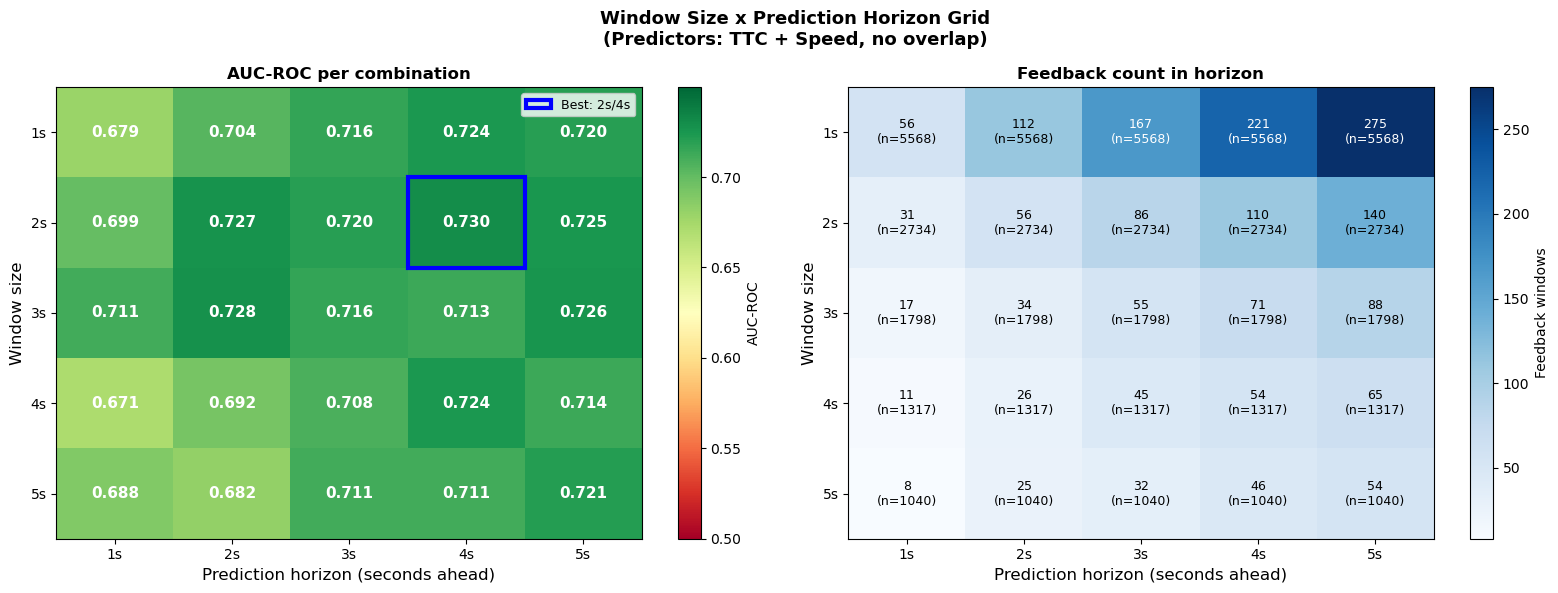

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Window Size x Prediction Horizon Grid\n(Predictors: TTC + Speed, no overlap)',
             fontsize=13, fontweight='bold')

# AUC heatmap
ax = axes[0]
vmax = np.nanmax(auc_grid)
im   = ax.imshow(auc_grid, vmin=0.5, vmax=min(vmax+0.02, 1.0), cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='AUC-ROC')
ax.set_xticks(range(5)); ax.set_xticklabels([f'{h}s' for h in horizons])
ax.set_yticks(range(5)); ax.set_yticklabels([f'{w}s' for w in wins])
ax.set_xlabel('Prediction horizon (seconds ahead)', fontsize=12)
ax.set_ylabel('Window size', fontsize=12)
ax.set_title('AUC-ROC per combination', fontsize=12, fontweight='bold')
for i in range(5):
    for j in range(5):
        v = auc_grid[i,j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=11, fontweight='bold',
                    color='white' if v > (0.5+(vmax-0.5)*0.6) else 'black')
        else:
            ax.text(j, i, 'N/A', ha='center', va='center', fontsize=9, color='grey')
ax.add_patch(plt.Rectangle((best_j-0.5, best_i-0.5), 1, 1,
             fill=False, edgecolor='blue', lw=3, label=f'Best: {wins[best_i]}s/{horizons[best_j]}s'))
ax.legend(loc='upper right', fontsize=9)

# Feedback count heatmap
ax = axes[1]
im2 = ax.imshow(fb_grid, cmap='Blues', aspect='auto')
plt.colorbar(im2, ax=ax, label='Feedback windows')
ax.set_xticks(range(5)); ax.set_xticklabels([f'{h}s' for h in horizons])
ax.set_yticks(range(5)); ax.set_yticklabels([f'{w}s' for w in wins])
ax.set_xlabel('Prediction horizon (seconds ahead)', fontsize=12)
ax.set_ylabel('Window size', fontsize=12)
ax.set_title('Feedback count in horizon', fontsize=12, fontweight='bold')
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{fb_grid[i,j]}\n(n={n_grid[i,j]})', ha='center', va='center',
                fontsize=9, color='white' if fb_grid[i,j] > fb_grid.max()*0.6 else 'black')

plt.tight_layout()
plt.savefig('output/fig_heatmap_window_horizon.png', dpi=140, bbox_inches='tight')
plt.show()

## Heatmap per Segment

אותו ניסוי 5x5, אבל מופרד לפי סגמנט.

- **Seg 1** — מנבא: `TTC_min` (TTC מוגדר לפני הצומת)
- **Seg 2** — מנבא: `Speed_mean` (TTC לא מוגדר בחלק מהחלונות)
- **Seg 3** — מנבא: `Speed_mean` (TTC לא מוגדר כלל)

כל heatmap מציג AUC לפי גודל חלון x אופק חיזוי — ללא חפיפה.

In [38]:
def build_windows_seg(df, seg_id, feature_col, win_sec, horizon_sec):
    seg_df = df[df['segment'] == seg_id].copy()
    rows = []
    for ev_id, g in seg_df.groupby('event_id'):
        g = g.sort_values('start_time').reset_index(drop=True)
        t_start = g['start_time'].min()
        t_end   = g['start_time'].max() + 1
        t = t_start
        while t + win_sec <= t_end:
            win_mask = (g['start_time'] >= t) & (g['start_time'] < t + win_sec)
            hor_mask = (g['start_time'] >= t + win_sec) & (g['start_time'] < t + win_sec + horizon_sec)
            win_rows = g[win_mask]
            hor_rows = g[hor_mask]
            if len(win_rows) == 0:
                t += win_sec; continue
            feat   = win_rows[feature_col].mean() if feature_col == 'Speed_mean' else win_rows[feature_col].min()
            target = 1 if (len(hor_rows) > 0 and hor_rows['first_feedback_relavet_to_event'].max() == 1) else 0
            rows.append({'feature': feat, 'target': target})
            t += win_sec
    return pd.DataFrame(rows)

wins     = [1, 2, 3, 4, 5]
horizons = [1, 2, 3, 4, 5]

seg_configs = [
    (1.0, 'TTC_imputed', 'Seg 1 — Approaching (TTC_min)', '#4878d0'),
    (2.0, 'Speed_mean',  'Seg 2 — Yellow decision (Speed_mean)', '#ee854a'),
    (3.0, 'Speed_mean',  'Seg 3 — Junction (Speed_mean)', '#9467bd'),
]

grids = {}
for seg_id, feat, title, color in seg_configs:
    auc_g = np.full((5,5), np.nan)
    fb_g  = np.zeros((5,5), dtype=int)
    n_g   = np.zeros((5,5), dtype=int)
    for i, w in enumerate(wins):
        for j, h in enumerate(horizons):
            wdf = build_windows_seg(df, seg_id, feat, w, h)
            y   = wdf['target'].values
            n_g[i,j]  = len(wdf)
            fb_g[i,j] = y.sum()
            if y.sum() < 3 or (1-y).sum() < 3:
                continue
            X = wdf[['feature']].fillna(6.0).values
            m = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500).fit(X, y)
            auc_g[i,j] = roc_auc_score(y, m.predict_proba(X)[:,1])
    grids[seg_id] = (auc_g, fb_g, n_g, title, color)
    best_i, best_j = np.unravel_index(np.nanargmax(auc_g), auc_g.shape)
    print(f'{title}')
    print(f'  Best: window={wins[best_i]}s  horizon={horizons[best_j]}s  AUC={auc_g[best_i,best_j]:.3f}')
    print(pd.DataFrame(auc_g.round(3),
                       index=[f'{w}s' for w in wins],
                       columns=[f'{h}s' for h in horizons]))
    print()

Seg 1 — Approaching (TTC_min)
  Best: window=4s  horizon=2s  AUC=0.653
       1s     2s     3s     4s     5s
1s  0.605  0.581  0.566  0.552  0.532
2s  0.538  0.570  0.543  0.556  0.505
3s  0.528  0.595  0.579  0.510  0.533
4s    NaN  0.653  0.553  0.553  0.528
5s    NaN  0.480  0.526  0.556  0.556

Seg 2 — Yellow decision (Speed_mean)
  Best: window=5s  horizon=4s  AUC=0.639
       1s     2s     3s     4s     5s
1s  0.562  0.568  0.575  0.586  0.600
2s  0.570  0.575  0.576  0.591  0.606
3s  0.546  0.515  0.594  0.592  0.590
4s  0.546  0.569  0.599  0.587  0.603
5s  0.626  0.620  0.624  0.639  0.628

Seg 3 — Junction (Speed_mean)
  Best: window=2s  horizon=3s  AUC=0.643
       1s     2s     3s     4s     5s
1s  0.534  0.538  0.557  0.551  0.531
2s    NaN    NaN  0.643  0.643  0.577
3s    NaN    NaN    NaN    NaN  0.512
4s    NaN    NaN    NaN    NaN    NaN
5s    NaN    NaN    NaN    NaN    NaN



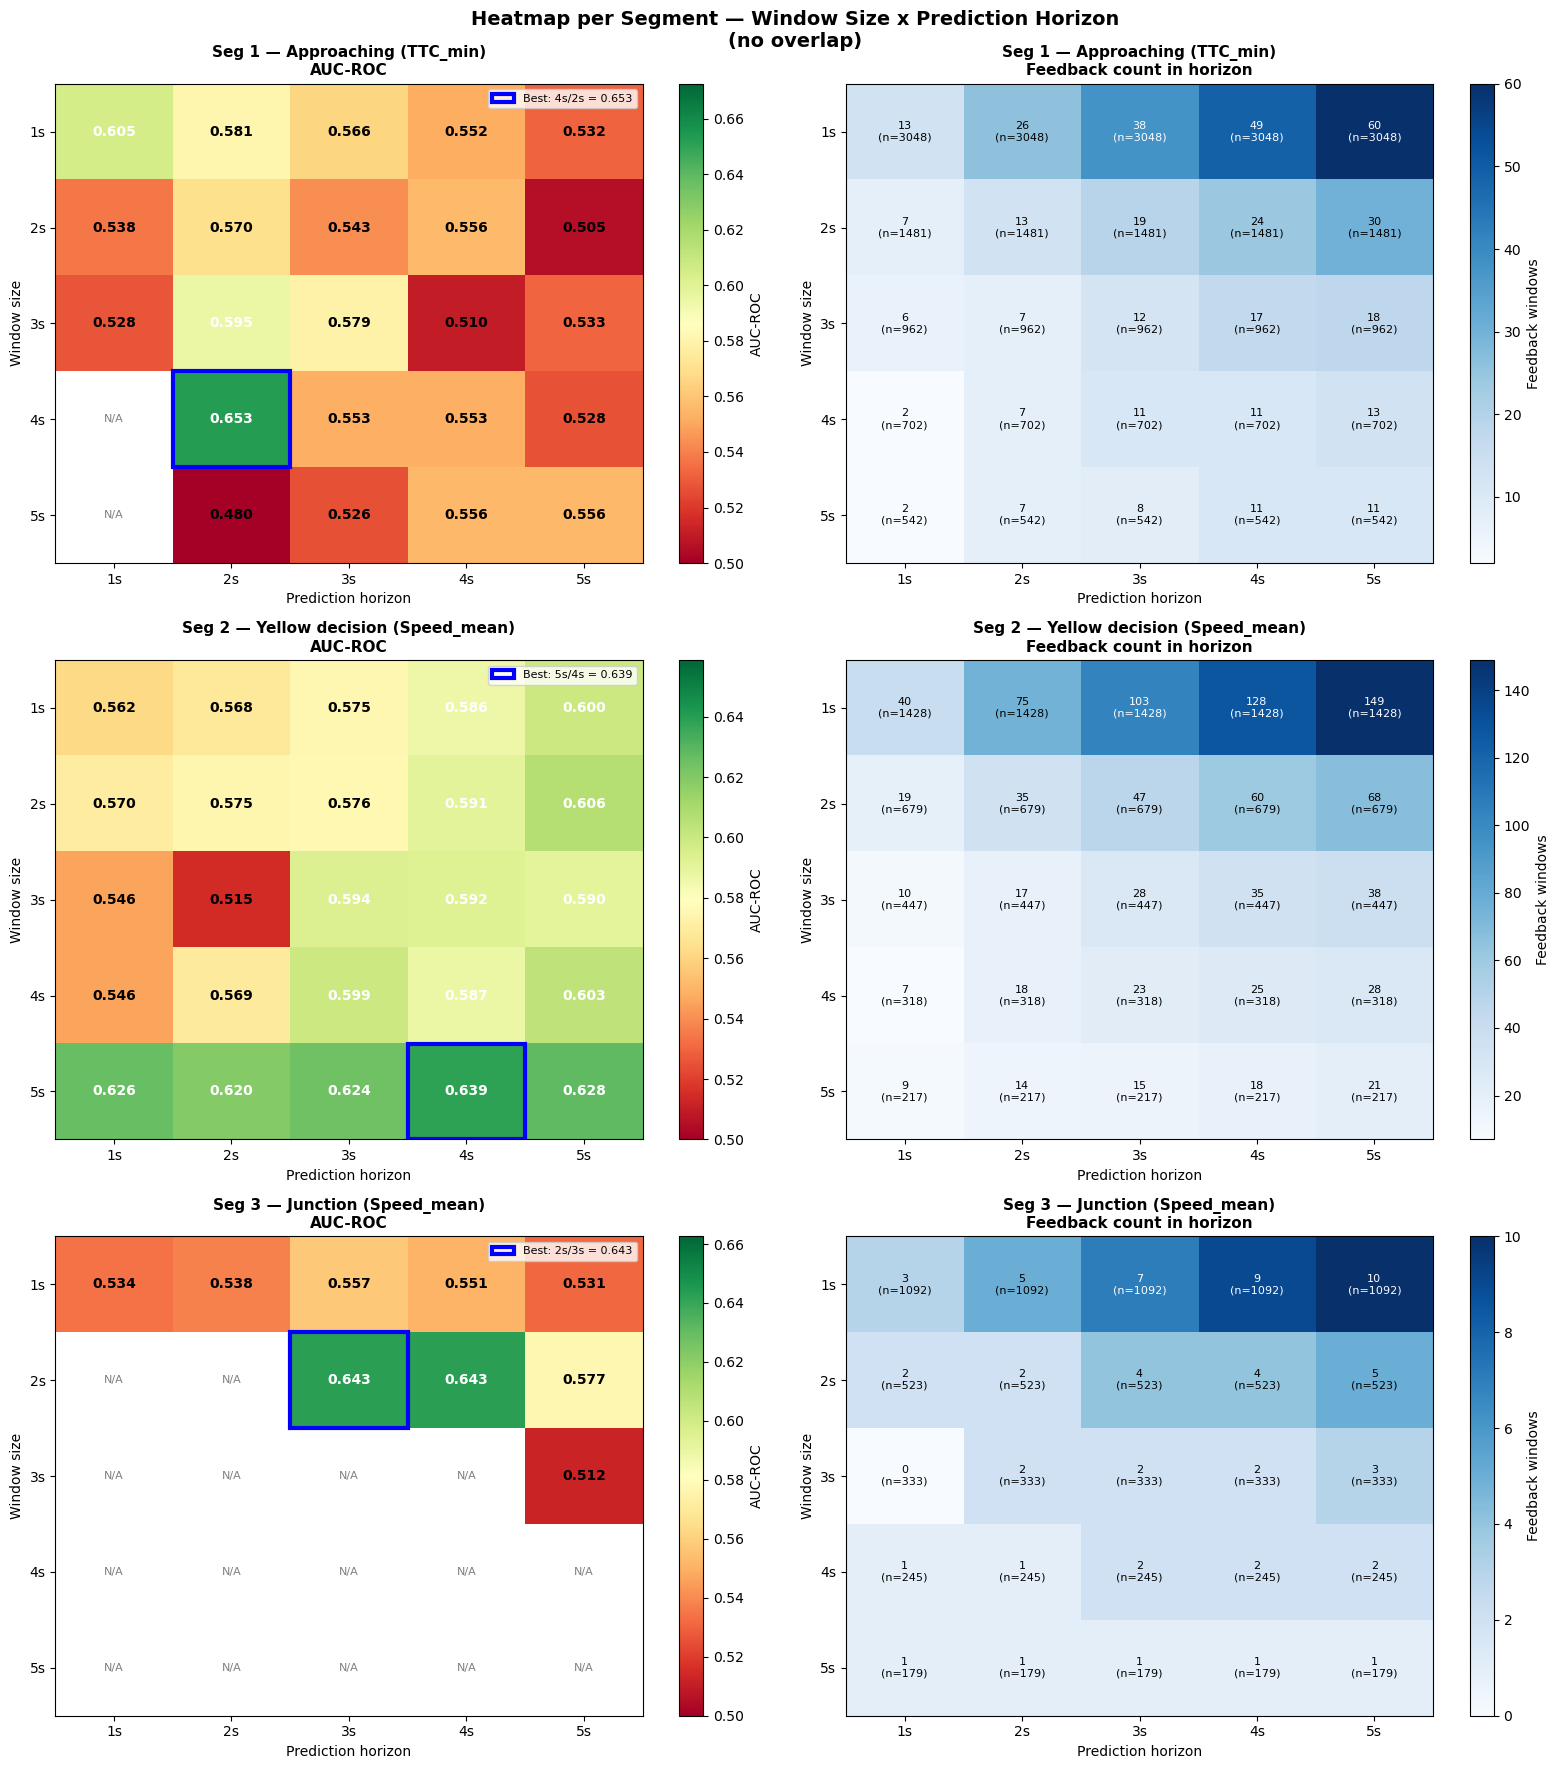

In [39]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Heatmap per Segment — Window Size x Prediction Horizon\n(no overlap)',
             fontsize=14, fontweight='bold')

for row_idx, (seg_id, feat, title, color) in enumerate(seg_configs):
    auc_g, fb_g, n_g, title, color = grids[seg_id]
    vmax = np.nanmax(auc_g) if not np.all(np.isnan(auc_g)) else 0.8

    # AUC heatmap
    ax = axes[row_idx][0]
    im = ax.imshow(auc_g, vmin=0.5, vmax=min(vmax+0.02,1.0), cmap='RdYlGn', aspect='auto')
    plt.colorbar(im, ax=ax, label='AUC-ROC')
    ax.set_xticks(range(5)); ax.set_xticklabels([f'{h}s' for h in horizons])
    ax.set_yticks(range(5)); ax.set_yticklabels([f'{w}s' for w in wins])
    ax.set_xlabel('Prediction horizon', fontsize=10)
    ax.set_ylabel('Window size', fontsize=10)
    ax.set_title(f'{title}\nAUC-ROC', fontsize=11, fontweight='bold')
    for i in range(5):
        for j in range(5):
            v = auc_g[i,j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=10, fontweight='bold',
                        color='white' if v > (0.5+(vmax-0.5)*0.6) else 'black')
            else:
                ax.text(j, i, 'N/A', ha='center', va='center', fontsize=8, color='grey')
    if not np.all(np.isnan(auc_g)):
        bi, bj = np.unravel_index(np.nanargmax(auc_g), auc_g.shape)
        ax.add_patch(plt.Rectangle((bj-0.5, bi-0.5), 1, 1,
                     fill=False, edgecolor='blue', lw=3,
                     label=f'Best: {wins[bi]}s/{horizons[bj]}s = {auc_g[bi,bj]:.3f}'))
        ax.legend(loc='upper right', fontsize=8)

    # Feedback count heatmap
    ax = axes[row_idx][1]
    im2 = ax.imshow(fb_g, cmap='Blues', aspect='auto')
    plt.colorbar(im2, ax=ax, label='Feedback windows')
    ax.set_xticks(range(5)); ax.set_xticklabels([f'{h}s' for h in horizons])
    ax.set_yticks(range(5)); ax.set_yticklabels([f'{w}s' for w in wins])
    ax.set_xlabel('Prediction horizon', fontsize=10)
    ax.set_ylabel('Window size', fontsize=10)
    ax.set_title(f'{title}\nFeedback count in horizon', fontsize=11, fontweight='bold')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{fb_g[i,j]}\n(n={n_g[i,j]})', ha='center', va='center',
                    fontsize=8, color='white' if fb_g[i,j] > fb_g.max()*0.6 else 'black')

plt.tight_layout()
plt.savefig('output/fig_heatmap_per_segment.png', dpi=140, bbox_inches='tight')
plt.show()